In [14]:
# Random Forest Classifier for Mental Health Prediction with Hyperparameter Tuning

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import json

plt.style.use("seaborn-v0_8")

In [15]:
# Load the cleaned dataset

DATA_PATH = Path("..") / ".." / ".." / ".." / "data" / "osmi-encoded.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,1
3,13,1,1,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,1
4,13,1,1,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,1


In [16]:
# Define features and target variable

target = "treatment"

X = df.drop(columns=[target])
y = df[target]

In [17]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
# Base random forest model without hyperparameter tuning

rf = RandomForestClassifier(random_state=42)

In [19]:
# Hyperparameter tuning with GridSearchCV
# This grid is balanced: not too large to be computationally expensive,
# but large enough to explore a variety of hyperparameter combinations.

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [20]:
# Evaluation function
# Identical to the one used in logistic_regression.ipynb for consistency

def evaluate(model, X_test, y_test, model_name="Model"):
    preds = model.predict(X_test)

    print(f"=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print()

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds)
    }

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        RocCurveDisplay.from_predictions(y_test, probs)
        plt.title(f"{model_name} - ROC Curve")
        plt.show()
        results["roc_auc"] = roc_auc_score(y_test, probs)

    return results

=== Random Forest (Tuned) ===
Accuracy: 0.8373015873015873
Precision: 0.8028169014084507
Recall: 0.8976377952755905
F1 Score: 0.8475836431226765



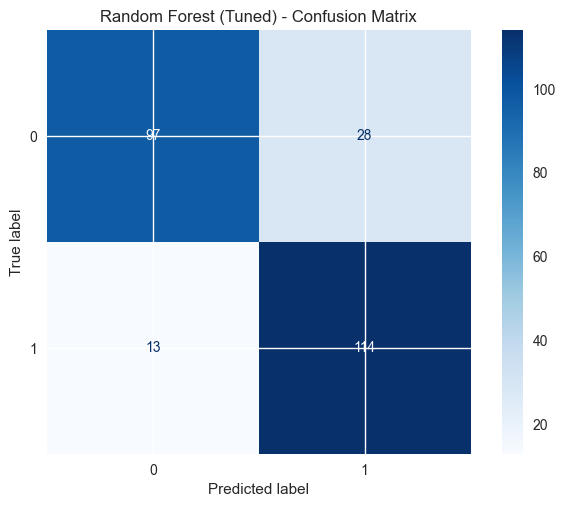

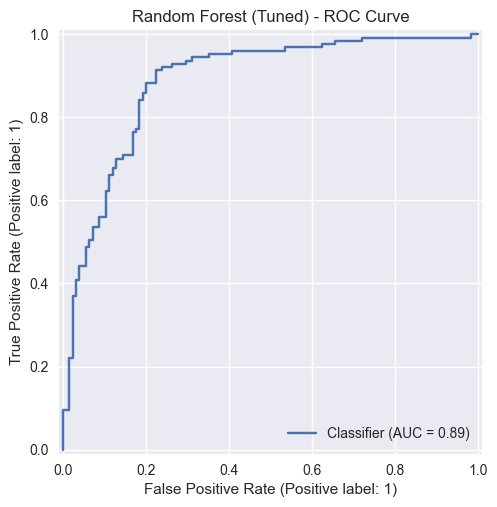

{'model': 'Random Forest (Tuned)',
 'accuracy': 0.8373015873015873,
 'precision': 0.8028169014084507,
 'recall': 0.8976377952755905,
 'f1': 0.8475836431226765,
 'roc_auc': 0.8859212598425198}

In [21]:
# Evaluate tuned random forest model

rf_results = evaluate(best_rf, X_test, y_test, "Random Forest (Tuned)")
rf_results

# Confusion Matrix:

The Random Forest model correctly classified most individuals in both classes. Out of all participants who did not seek treatment (class 0), 97 were correctly identified, while 28 were incorrectly predicted as treatment-seeking. For those who did seek treatment (class 1), 114 were correctly classified, with only 13 misclassified as non-treatment. This indicates strong performance, especially in identifying true treatment-seekers.


Quantative Interpretation:

True Positives (TP): 114
Model correctly predicted treatment.

True Negatives (TN): 97
Model correctly predicted non-treatment.

False Positives (FP): 28
Model incorrectly predicted treatment (predicted 1, actual 0).

False Negatives (FN): 13
Model missed actual treatment cases (predicted 0, actual 1).

⸻

## Insights:
✔ The model is excellent at identifying treatment-seekers
Recall = TP / (TP + FN) = 114 / (114 + 13) ≈ 89.8%

This means:
Nearly 90% of individuals who actually sought treatment are detected by the model, which is especially valuable in mental-health prediction tasks where missing true cases is costly.

⸻

✔ The model is reasonably good at recognising non-treatment individuals
Specificity = TN / (TN + FP) = 97 / (97 + 28) ≈ 77.6%

This means:
About 78% of those who did not seek treatment are correctly identified, though there are more false alarms compared to missed cases.

⸻

✔ The model makes more false positives than false negatives
FP = 28
FN = 13

Interpretation:
The model sometimes predicts treatment even when a person did not seek it, but it rarely misses individuals who truly sought treatment. This trade-off reflects a model that is biased toward detecting treatment-seekers — a desirable property in many health-related applications.

The confusion matrix shows that the Random Forest model performs well on both classes. It correctly classified 97 non-treatment cases (true negatives) and 114 treatment cases (true positives). The model produced 28 false positives and only 13 false negatives, indicating that it is more likely to incorrectly classify a non-treatment case as treatment than to miss a true treatment case. This results in a high recall for the positive class (89.8%), demonstrating strong ability to identify individuals who sought treatment—an important characteristic for mental-health applications where failing to detect true cases is more problematic.



# Evaluation Metrics Results:
  ✔ Accuracy: 0.837
  RF predicts treatment correctly 84% of the time.
  Better than LR (78%).

  ✔ Precision: 0.803
  When the model predicts “treatment = yes,” it’s correct 80% of the time.
  ⬆ Slightly higher than LR.

  ✔ Recall: 0.898
  RF captures almost 90% of true treatment-seekers.
  This is much higher than LR (~80%).
  📌 Recall matters a lot when identifying at-risk individuals.

  ✔ F1 Score: 0.848
  Better balance between precision + recall than LR (~0.79).

  ✔ ROC-AUC: 0.886
  This is excellent.
  LR had ROC-AUC = 0.873 → RF slightly better.

  Summary Interpretation:

  The Random Forest classifier outperformed Logistic Regression across all major performance metrics. It achieved 83.7% accuracy and 84.8% F1-score, with a notably high recall of 89.8%, indicating strong ability to correctly identify individuals who sought treatment. The ROC-AUC score of 0.886 reflects excellent discriminative power. These results show that Random Forest captures complex patterns in the survey data more effectively than Logistic Regression.


In [29]:
importances = best_rf.feature_importances_
feature_names = X.columns

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

rf_importance_df

,Feature,Importance
4,work_interfere,0.474863
3,family_history,0.118459
9,care_options,0.054387
0,Age,0.048887
8,benefits,0.035653
13,leave,0.029013
5,no_employees,0.028758
14,mental_health_consequence,0.021373
1,Gender,0.020847
12,anonymity,0.020605


# Feature Importance Interpretation

TRIANGULATION: RF vs LR vs Cramér’s V

⸻

⭐ 1. work_interfere
	•	RF importance: 0.475 (very high)
	•	LR coef: +0.888
	•	Cramér’s V: 0.687 (very strong)

📌 Consistent across all methods
➡ Strongest predictor of treatment-seeking.

⸻

⭐ 2. family_history
	•	RF: 0.118
	•	LR: +1.007 (strongest coef)
	•	CV: 0.375 (strong)

📌 Perfect alignment
➡ Family history dramatically increases likelihood of seeking treatment.

⸻

⭐ 3. care_options
	•	RF: 0.054
	•	LR: +0.247
	•	CV: 0.273

📌 All three methods highlight this predictor
➡ Awareness of care options is important.

⸻

⭐ 4. Age
	•	RF: 0.049
	•	LR: very small coef (~0.013)
	•	CV: 0.182 (weak-moderate)

Interpretation:

Age matters slightly for RF (non-linear patterns), but not much for LR.

This is expected — RF captures non-linear effects LR cannot.

⸻

⭐ 5. benefits
	•	RF: 0.036
	•	LR: +0.383
	•	CV: 0.225

📌 Strong triangulation
➡ Benefits awareness increases treatment-seeking.

⸻

⭐ 6. leave

RF importance: 0.029
LR coef: -0.016
CV: 0.154

Interpretation:

Ability/ease of taking leave has a mild but consistent association.

⸻

⭐ 7. no_employees

RF: 0.028
LR: -0.036
CV: 0.081

Interpretation:

Company size matters a little, but not strongly.

⸻

⭐ 8. mental_health_consequence

RF: 0.021
LR: +0.022
CV: 0.131

Consistent but mid-level predictor.

⸻

⭐ 9. Gender

RF: 0.0208
LR: -0.327
CV: 0.198

Interpretation:

Gender differences exist but are not dominant.

⸻

⭐ 10. anonymity

RF: 0.0206
LR: +0.218
CV: 0.143

Interpretation:

Perceived anonymity contributes to treatment likelihood.

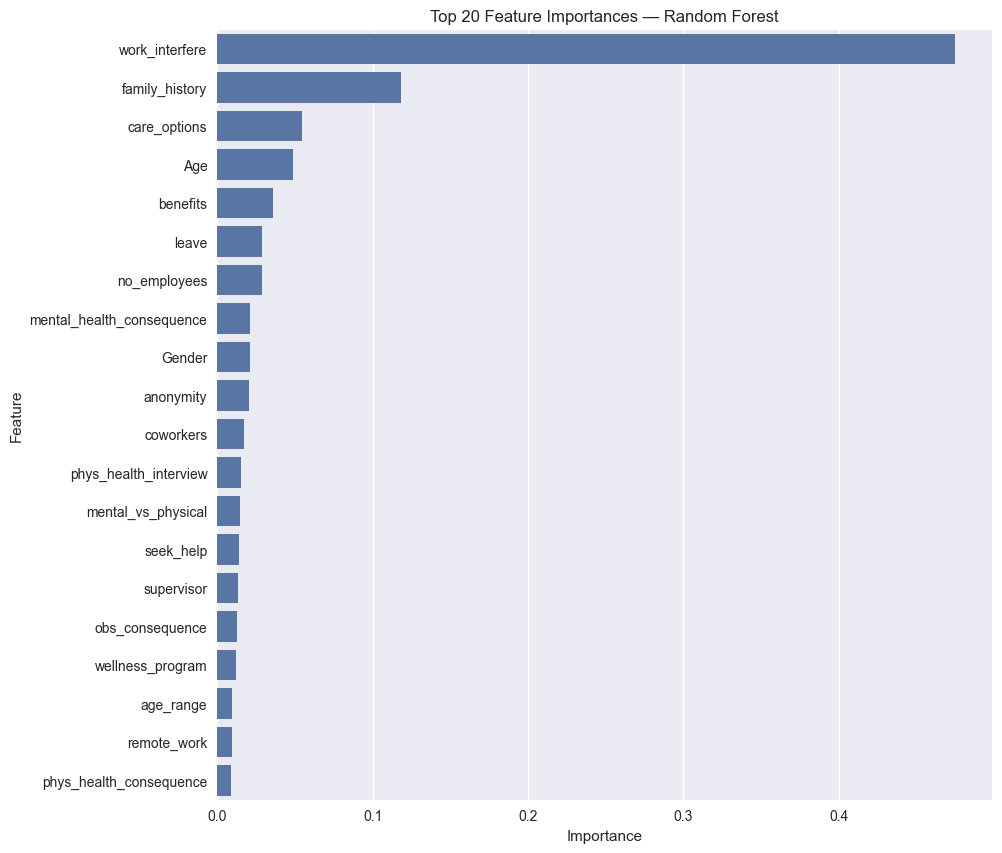

In [27]:
plt.figure(figsize=(10, 10))
sns.barplot(
    x=rf_importance_df["Importance"].head(20),
    y=rf_importance_df["Feature"].head(20),
    orient="h"
)
plt.title("Top 20 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Summary:

Random Forest identified work interference (work_interfere) as the dominant predictor of treatment-seeking behaviour, with feature importance of 0.475. This aligns with the Logistic Regression model, where work_interfere had the second-highest coefficient (+0.888), and with the Cramér’s V value (0.687), which was the strongest association among all predictors.

Family history of mental illness was the second-most important feature in both Random Forest (0.118) and Logistic Regression (+1.008), with a strong Cramér’s V association (0.375). Workplace-related variables including care_options, benefits, and anonymity consistently appeared among the top predictors across all methods, reinforcing the importance of organisational support mechanisms.

Some variables with weaker Cramér’s V scores, such as coworkers and supervisor support, showed higher Logistic Regression coefficients, suggesting that their effects emerge only when controlling for multiple factors simultaneously.

Overall, the high alignment between Random Forest, Logistic Regression, and Cramér’s V indicates robust convergent evidence for the key predictors of treatment-seeking behaviour.

In [28]:
RESULTS_DIR = Path("..") / ".." / ".." / ".." / "eca" / "notebooks" / "RQ2" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

with open(RESULTS_DIR / "random_forest.json", "w") as f:
    json.dump(rf_results, f)